# 06 — Cell–Cell Communication Analysis

## Objective

This notebook explores potential ligand–receptor interactions among major
cellular compartments within the CID4465 triple-negative breast cancer
tumor microenvironment.

The analysis aims to:

1. Prepare major cell populations for ligand–receptor inference.
2. Identify candidate intercellular communication events using LIANA+.
3. Characterize signaling involving cancer epithelial, immune, stromal,
   and endothelial populations.
4. Highlight candidate ligand–receptor interactions relevant to the TNBC
   tumor microenvironment.

Because the dataset represents a single tumor sample, the analysis is
exploratory and does not infer condition-specific differential communication.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util

print("Scanpy version:", sc.__version__)
print("LIANA installed:", importlib.util.find_spec("liana") is not None)

Scanpy version: 1.12.4
LIANA installed: False


/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_7478/3816401095.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [3]:
import liana as li

print("LIANA version:", li.__version__)

LIANA version: 1.10.0


In [4]:
project_dir = Path("..")

data_dir = project_dir / "data" / "processed"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

adata_path = data_dir / "CID4465_processed.h5ad"

adata = sc.read_h5ad(adata_path)

print(adata)
print("\nShape:", adata.shape)

AnnData object with n_obs × n_vars = 1534 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Shape: (1534, 13514)


In [5]:
print("=== LIANA INPUT CHECK ===")

print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\nRaw available:")
print(adata.raw is not None)

print("\nLayers:")
print(list(adata.layers.keys()))

print("\nMajor cell types:")
print(
    adata.obs["celltype_major"]
    .value_counts()
)

=== LIANA INPUT CHECK ===
Cells: 1534
Genes: 13514

Raw available:
False

Layers:
['counts', None]

Major cell types:
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Normal Epithelial      9
Name: count, dtype: int64


In [6]:
print("Expression matrix range:")

print("X min:", adata.X.min())
print("X max:", adata.X.max())

print("\nCounts layer range:")
print("Counts min:", adata.layers["counts"].min())
print("Counts max:", adata.layers["counts"].max())

print("\nlog1p metadata:")
print(adata.uns.get("log1p"))

Expression matrix range:
X min: 0.0
X max: 9.024438

Counts layer range:
Counts min: 0
Counts max: 5167

log1p metadata:
{'base': None}


In [7]:
print("Expression matrix range:")
print("X min:", adata.X.min())
print("X max:", adata.X.max())

print("\nCounts layer range:")
print("Counts min:", adata.layers["counts"].min())
print("Counts max:", adata.layers["counts"].max())

print("\nlog1p metadata:")
print(adata.uns.get("log1p"))

Expression matrix range:
X min: 0.0
X max: 9.024438

Counts layer range:
Counts min: 0
Counts max: 5167

log1p metadata:
{'base': None}


In [8]:
use_raw=False

In [9]:
# Prepare cell populations for cell-cell communication analysis

major_groups = [
    "CAFs",
    "PVL",
    "Endothelial",
    "Myeloid",
    "T-cells",
    "Cancer Epithelial",
    "Plasmablasts",
    "B-cells"
]

adata_liana = adata[
    adata.obs["celltype_major"].isin(major_groups)
].copy()

print("LIANA analysis dataset:")
print(adata_liana)

print("\nCell-type composition:")
print(
    adata_liana.obs["celltype_major"]
    .value_counts()
)

LIANA analysis dataset:
AnnData object with n_obs × n_vars = 1525 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Cell-type composition:
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Name: count, dtype: int64


In [10]:
print("=== PRE-LIANA QC ===")

print("Cells:", adata_liana.n_obs)
print("Genes:", adata_liana.n_vars)

print("\nGroups:")
print(adata_liana.obs["celltype_major"].value_counts())

print("\nExpression range:")
print("Min:", adata_liana.X.min())
print("Max:", adata_liana.X.max())

print("\nAny missing cell-type labels:")
print(adata_liana.obs["celltype_major"].isna().sum())

=== PRE-LIANA QC ===
Cells: 1525
Genes: 13514

Groups:
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Name: count, dtype: int64

Expression range:
Min: 0.0
Max: 9.024438

Any missing cell-type labels:
0


In [11]:
# Run LIANA consensus ligand-receptor inference

li.mt.rank_aggregate(
    adata_liana,
    groupby="celltype_major",
    use_raw=False,
    expr_prop=0.1,
    resource_name="consensus",
    verbose=True
)

Using resource `consensus`.
Using `.X`!
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.44 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 1525 samples and 929 features


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:02<00:00, 467.84it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [12]:
adata_liana.uns["liana_res"]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
310,CAFs,Cancer Epithelial,LUM,ITGB1,2.980652,0.000,6.377883,0.960594,2.696130,0.149709,0.962911,0.017688,0.000011
499,CAFs,PVL,LUM,ITGB1,2.914942,0.000,5.778110,0.910978,3.235507,0.135630,0.961106,0.017688,0.000044
1118,Endothelial,T-cells,HLA-B,CD3D,2.669198,0.000,6.427697,1.382267,2.425714,0.151759,0.963049,0.015679,0.000176
231,CAFs,CAFs,LUM,ITGB1,2.794617,0.000,4.679827,0.820125,2.805457,0.109850,0.956969,0.017688,0.000223
1337,Myeloid,T-cells,HLA-B,CD3D,2.483868,0.000,5.747765,1.267807,2.146989,0.135705,0.961008,0.017688,0.000275
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Cancer Epithelial,CAFs,LRPAP1,LRP1,0.406629,0.000,0.142801,0.259784,0.674201,0.076363,0.795282,0.169622,1.000000
1678,Plasmablasts,Endothelial,MMP7,CD151,0.430631,0.004,0.179474,0.145441,-0.066156,0.028138,0.813263,0.793627,1.000000
1680,Plasmablasts,Endothelial,S100A9,CD36,0.547255,0.000,0.127248,0.293238,0.490168,0.041568,0.785735,0.363307,1.000000
614,Cancer Epithelial,Cancer Epithelial,APP,TSPAN12,0.395915,0.000,0.144152,0.402219,0.341229,0.129608,0.796047,0.241802,1.000000


In [13]:
liana_res = adata_liana.uns["liana_res"].copy()

print("LIANA result shape:", liana_res.shape)
print("\nColumns:")
print(liana_res.columns.tolist())

print("\nFirst 10 interactions:")
print(liana_res.head(10))

LIANA result shape: (1807, 13)

Columns:
['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means', 'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc', 'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank']

First 10 interactions:
                 source             target ligand_complex receptor_complex  \
310                CAFs  Cancer Epithelial            LUM            ITGB1   
499                CAFs                PVL            LUM            ITGB1   
1118        Endothelial            T-cells          HLA-B             CD3D   
231                CAFs               CAFs            LUM            ITGB1   
1337            Myeloid            T-cells          HLA-B             CD3D   
252                CAFs               CAFs          TIMP1             CD63   
804   Cancer Epithelial            T-cells           CD59              CD2   
1397                PVL               CAFs          TIMP1             CD63   
1803            T-cells            T-

In [14]:
print(
    liana_res.head(20)[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ]
)

                 source             target ligand_complex receptor_complex  \
310                CAFs  Cancer Epithelial            LUM            ITGB1   
499                CAFs                PVL            LUM            ITGB1   
1118        Endothelial            T-cells          HLA-B             CD3D   
231                CAFs               CAFs            LUM            ITGB1   
1337            Myeloid            T-cells          HLA-B             CD3D   
252                CAFs               CAFs          TIMP1             CD63   
804   Cancer Epithelial            T-cells           CD59              CD2   
1397                PVL               CAFs          TIMP1             CD63   
1803            T-cells            T-cells          HLA-B             CD3D   
395                CAFs        Endothelial            LUM            ITGB1   
307                CAFs  Cancer Epithelial         LGALS1            ITGB1   
367                CAFs        Endothelial         COL1A2       

In [15]:
tumor_interactions = liana_res[
    (liana_res["source"] == "Cancer Epithelial") |
    (liana_res["target"] == "Cancer Epithelial")
].copy()

print("Tumor-centered interactions:", tumor_interactions.shape)

print(
    tumor_interactions.head(30)[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ]
)

Tumor-centered interactions: (615, 13)
                 source             target ligand_complex receptor_complex  \
310                CAFs  Cancer Epithelial            LUM            ITGB1   
804   Cancer Epithelial            T-cells           CD59              CD2   
307                CAFs  Cancer Epithelial         LGALS1            ITGB1   
725   Cancer Epithelial            Myeloid            APP             CD74   
642   Cancer Epithelial  Cancer Epithelial         LGALS9           SLC1A5   
777   Cancer Epithelial                PVL            MDK             SDC2   
625   Cancer Epithelial  Cancer Epithelial         COL1A2             SDC1   
675   Cancer Epithelial        Endothelial            APP             CD74   
646   Cancer Epithelial  Cancer Epithelial            MDK              NCL   
1204            Myeloid  Cancer Epithelial         LGALS1            ITGB1   
1435                PVL  Cancer Epithelial         LGALS1            ITGB1   
1647       Plasmablasts  

In [16]:
# Keep only communication between tumor cells and other TME compartments

tumor_tme = tumor_interactions[
    ~(
        (tumor_interactions["source"] == "Cancer Epithelial") &
        (tumor_interactions["target"] == "Cancer Epithelial")
    )
].copy()

print("Tumor–TME interactions:", tumor_tme.shape)

Tumor–TME interactions: (553, 13)


In [17]:
top_tumor_tme = tumor_tme[
    (tumor_tme["magnitude_rank"] < 0.05) &
    (tumor_tme["specificity_rank"] < 0.05)
].copy()

top_tumor_tme = top_tumor_tme.sort_values(
    ["magnitude_rank", "specificity_rank"]
)

print("High-confidence exploratory interactions:", top_tumor_tme.shape)

print(
    top_tumor_tme[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ].to_string(index=False)
)

High-confidence exploratory interactions: (9, 13)
           source            target ligand_complex receptor_complex  magnitude_rank  specificity_rank
             CAFs Cancer Epithelial            LUM            ITGB1        0.000011          0.017688
Cancer Epithelial           T-cells           CD59              CD2        0.000537          0.011416
Cancer Epithelial               PVL            MDK             SDC2        0.009703          0.017688
Cancer Epithelial              CAFs            MDK             LRP1        0.015474          0.007769
Cancer Epithelial           Myeloid           COPA             CD74        0.023510          0.035340
Cancer Epithelial       Endothelial            MDK      ITGA6_ITGB1        0.024502          0.010561
Cancer Epithelial           Myeloid         S100A8             CD68        0.031431          0.000183
      Endothelial Cancer Epithelial            VWF            ITGB1        0.046364          0.017688
Cancer Epithelial           T-ce

In [18]:
# Summarize top interactions by source-target direction

interaction_directions = (
    top_tumor_tme
    .groupby(["source", "target"])
    .size()
    .reset_index(name="n_interactions")
    .sort_values("n_interactions", ascending=False)
)

print(interaction_directions)

              source             target  n_interactions
3  Cancer Epithelial            Myeloid               2
5  Cancer Epithelial            T-cells               2
0               CAFs  Cancer Epithelial               1
1  Cancer Epithelial               CAFs               1
2  Cancer Epithelial        Endothelial               1
4  Cancer Epithelial                PVL               1
6        Endothelial  Cancer Epithelial               1


In [19]:
# Extract top interactions within each tumor-TME direction

top_by_direction = (
    tumor_tme
    .sort_values(["magnitude_rank", "specificity_rank"])
    .groupby(["source", "target"], group_keys=False)
    .head(5)
)

print(
    top_by_direction[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ].to_string(index=False)
)

           source            target ligand_complex receptor_complex  magnitude_rank  specificity_rank
             CAFs Cancer Epithelial            LUM            ITGB1        0.000011          0.017688
Cancer Epithelial           T-cells           CD59              CD2        0.000537          0.011416
             CAFs Cancer Epithelial         LGALS1            ITGB1        0.001206          0.088544
Cancer Epithelial           Myeloid            APP             CD74        0.004345          0.060999
Cancer Epithelial               PVL            MDK             SDC2        0.009703          0.017688
Cancer Epithelial       Endothelial            APP             CD74        0.010025          0.126487
          Myeloid Cancer Epithelial         LGALS1            ITGB1        0.011714          0.529582
              PVL Cancer Epithelial         LGALS1            ITGB1        0.013531          0.414117
     Plasmablasts Cancer Epithelial            PKM             CD44        0.01491

In [20]:
liana_res.to_csv(
    results_dir / "06_liana_all_interactions.csv",
    index=False
)

tumor_tme.to_csv(
    results_dir / "06_tumor_tme_interactions.csv",
    index=False
)

top_tumor_tme.to_csv(
    results_dir / "06_top_tumor_tme_interactions.csv",
    index=False
)

print("LIANA result tables saved.")

LIANA result tables saved.


In [21]:
# Select exploratory high-ranking tumor-TME interactions

top_tumor_tme = tumor_tme[
    (tumor_tme["magnitude_rank"] < 0.05) &
    (tumor_tme["specificity_rank"] < 0.05)
].copy()

top_tumor_tme = top_tumor_tme.sort_values(
    ["magnitude_rank", "specificity_rank"]
)

print(
    "High-ranking exploratory tumor-TME interactions:",
    len(top_tumor_tme)
)

print(
    top_tumor_tme[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ].to_string(index=False)
)

High-ranking exploratory tumor-TME interactions: 9
           source            target ligand_complex receptor_complex  magnitude_rank  specificity_rank
             CAFs Cancer Epithelial            LUM            ITGB1        0.000011          0.017688
Cancer Epithelial           T-cells           CD59              CD2        0.000537          0.011416
Cancer Epithelial               PVL            MDK             SDC2        0.009703          0.017688
Cancer Epithelial              CAFs            MDK             LRP1        0.015474          0.007769
Cancer Epithelial           Myeloid           COPA             CD74        0.023510          0.035340
Cancer Epithelial       Endothelial            MDK      ITGA6_ITGB1        0.024502          0.010561
Cancer Epithelial           Myeloid         S100A8             CD68        0.031431          0.000183
      Endothelial Cancer Epithelial            VWF            ITGB1        0.046364          0.017688
Cancer Epithelial           T-c

In [22]:
interaction_directions = (
    top_tumor_tme
    .groupby(["source", "target"])
    .size()
    .reset_index(name="n_interactions")
    .sort_values(
        "n_interactions",
        ascending=False
    )
)

print(interaction_directions.to_string(index=False))

           source            target  n_interactions
Cancer Epithelial           Myeloid               2
Cancer Epithelial           T-cells               2
             CAFs Cancer Epithelial               1
Cancer Epithelial              CAFs               1
Cancer Epithelial       Endothelial               1
Cancer Epithelial               PVL               1
      Endothelial Cancer Epithelial               1


In [23]:
plot_df = top_tumor_tme.copy()

plot_df["interaction"] = (
    plot_df["ligand_complex"].astype(str)
    + " → "
    + plot_df["receptor_complex"].astype(str)
)

plot_df["direction"] = (
    plot_df["source"].astype(str)
    + " → "
    + plot_df["target"].astype(str)
)

plot_df["magnitude_score"] = (
    -np.log10(
        plot_df["magnitude_rank"].clip(lower=1e-10)
    )
)

plot_df["specificity_score"] = (
    -np.log10(
        plot_df["specificity_rank"].clip(lower=1e-10)
    )
)

print(
    plot_df[
        [
            "direction",
            "interaction",
            "magnitude_score",
            "specificity_score"
        ]
    ]
)

                           direction        interaction  magnitude_score  \
310         CAFs → Cancer Epithelial        LUM → ITGB1         4.957934   
804      Cancer Epithelial → T-cells         CD59 → CD2         3.269667   
777          Cancer Epithelial → PVL         MDK → SDC2         2.013093   
597         Cancer Epithelial → CAFs         MDK → LRP1         1.810398   
730      Cancer Epithelial → Myeloid        COPA → CD74         1.628747   
706  Cancer Epithelial → Endothelial  MDK → ITGA6_ITGB1         1.610792   
750      Cancer Epithelial → Myeloid      S100A8 → CD68         1.502646   
955  Endothelial → Cancer Epithelial        VWF → ITGB1         1.333821   
817      Cancer Epithelial → T-cells      S100A8 → CD69         1.308758   

     specificity_score  
310           1.752318  
804           1.942487  
777           1.752318  
597           2.109607  
730           1.451734  
706           1.976313  
750           3.737369  
955           1.752318  
817           

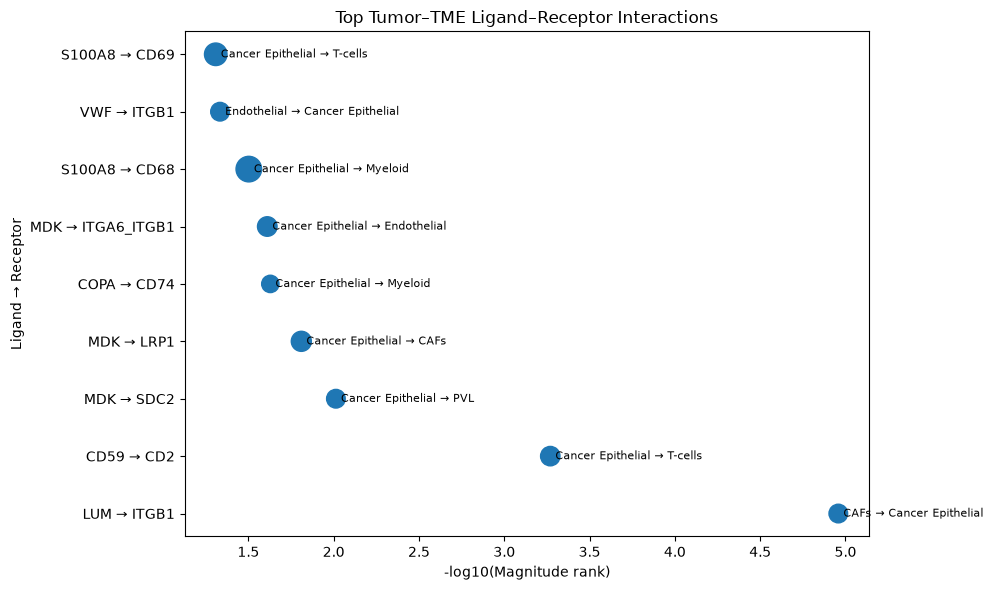

In [24]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    plot_df["magnitude_score"],
    plot_df["interaction"],
    s=plot_df["specificity_score"] * 80 + 40
)

for _, row in plot_df.iterrows():
    plt.text(
        row["magnitude_score"] + 0.03,
        row["interaction"],
        row["direction"],
        va="center",
        fontsize=8
    )

plt.xlabel("-log10(Magnitude rank)")
plt.ylabel("Ligand → Receptor")
plt.title("Top Tumor–TME Ligand–Receptor Interactions")

plt.tight_layout()
plt.show()

In [25]:
# Create concise summary of high-ranking tumor-TME interactions

communication_summary = top_tumor_tme[
    [
        "source",
        "target",
        "ligand_complex",
        "receptor_complex",
        "magnitude_rank",
        "specificity_rank"
    ]
].copy()

communication_summary["interaction"] = (
    communication_summary["ligand_complex"].astype(str)
    + " → "
    + communication_summary["receptor_complex"].astype(str)
)

communication_summary["direction"] = (
    communication_summary["source"].astype(str)
    + " → "
    + communication_summary["target"].astype(str)
)

communication_summary = communication_summary.sort_values(
    "magnitude_rank"
)

print(communication_summary.to_string(index=False))

           source            target ligand_complex receptor_complex  magnitude_rank  specificity_rank       interaction                       direction
             CAFs Cancer Epithelial            LUM            ITGB1        0.000011          0.017688       LUM → ITGB1        CAFs → Cancer Epithelial
Cancer Epithelial           T-cells           CD59              CD2        0.000537          0.011416        CD59 → CD2     Cancer Epithelial → T-cells
Cancer Epithelial               PVL            MDK             SDC2        0.009703          0.017688        MDK → SDC2         Cancer Epithelial → PVL
Cancer Epithelial              CAFs            MDK             LRP1        0.015474          0.007769        MDK → LRP1        Cancer Epithelial → CAFs
Cancer Epithelial           Myeloid           COPA             CD74        0.023510          0.035340       COPA → CD74     Cancer Epithelial → Myeloid
Cancer Epithelial       Endothelial            MDK      ITGA6_ITGB1        0.024502     

In [26]:
communication_summary.to_csv(
    results_dir / "06_high_ranking_tumor_tme_interactions.csv",
    index=False
)

interaction_directions.to_csv(
    results_dir / "06_tumor_tme_direction_summary.csv",
    index=False
)

print("Tumor-TME communication summaries saved.")

Tumor-TME communication summaries saved.


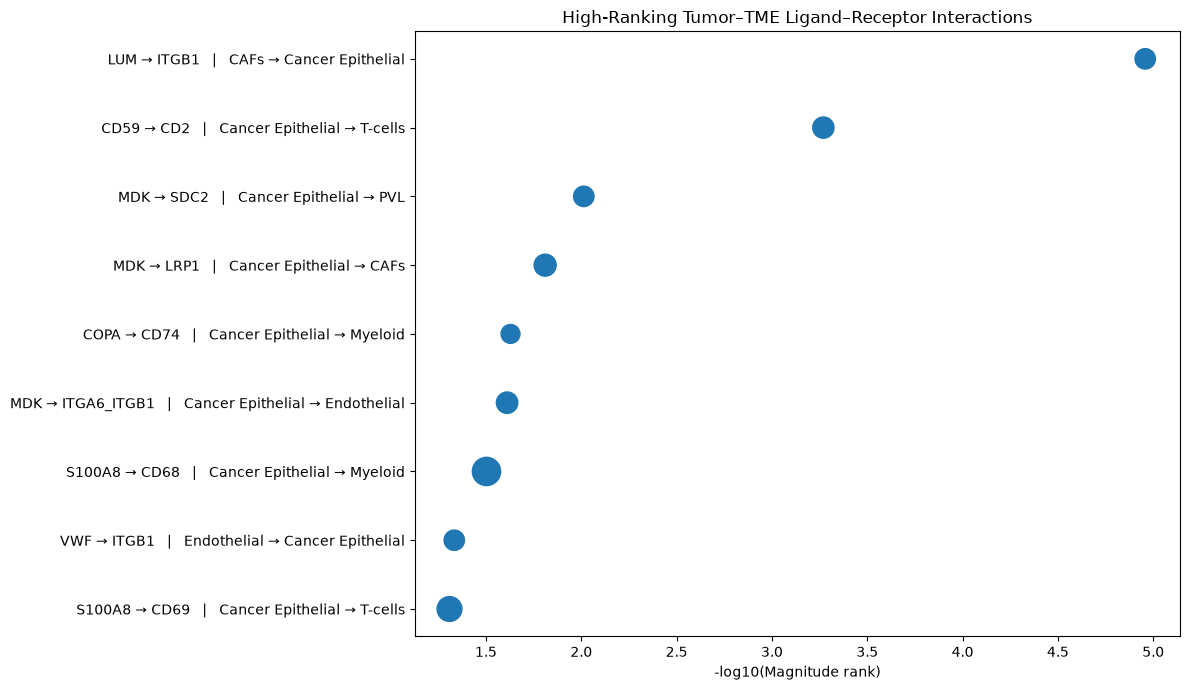

In [27]:
plot_df = communication_summary.copy()

plot_df["label"] = (
    plot_df["interaction"]
    + "   |   "
    + plot_df["direction"]
)

plot_df["magnitude_score"] = -np.log10(
    plot_df["magnitude_rank"].clip(lower=1e-10)
)

plot_df["specificity_score"] = -np.log10(
    plot_df["specificity_rank"].clip(lower=1e-10)
)

plot_df = plot_df.sort_values(
    "magnitude_score",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.scatter(
    plot_df["magnitude_score"],
    plot_df["label"],
    s=plot_df["specificity_score"] * 100 + 40
)

plt.xlabel("-log10(Magnitude rank)")
plt.ylabel("")
plt.title("High-Ranking Tumor–TME Ligand–Receptor Interactions")

plt.tight_layout()

plt.savefig(
    figures_dir / "06_top_tumor_tme_ligand_receptor_interactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
mdk_interactions = tumor_tme[
    tumor_tme["ligand_complex"] == "MDK"
].copy()

mdk_interactions = mdk_interactions.sort_values(
    "magnitude_rank"
)

print(
    mdk_interactions[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ].head(20).to_string(index=False)
)

           source            target ligand_complex receptor_complex  magnitude_rank  specificity_rank
Cancer Epithelial               PVL            MDK             SDC2        0.009703          0.017688
Cancer Epithelial              CAFs            MDK             LRP1        0.015474          0.007769
Cancer Epithelial       Endothelial            MDK      ITGA6_ITGB1        0.024502          0.010561
             CAFs Cancer Epithelial            MDK              NCL        0.051233          0.021628
Cancer Epithelial              CAFs            MDK             SDC2        0.071301          0.027011
Cancer Epithelial              CAFs            MDK             SDC1        0.124715          0.017688
Cancer Epithelial           B-cells            MDK              NCL        0.254758          0.188571
          Myeloid Cancer Epithelial            MDK      ITGA6_ITGB1        0.488745          1.000000
             CAFs Cancer Epithelial            MDK             SDC4        0.58000

In [29]:
itgb1_interactions = tumor_tme[
    (
        tumor_tme["target"] == "Cancer Epithelial"
    )
    &
    (
        tumor_tme["receptor_complex"]
        .astype(str)
        .str.contains("ITGB1")
    )
].copy()

itgb1_interactions = itgb1_interactions.sort_values(
    "magnitude_rank"
)

print(
    itgb1_interactions[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ].head(20).to_string(index=False)
)

      source            target ligand_complex receptor_complex  magnitude_rank  specificity_rank
        CAFs Cancer Epithelial            LUM            ITGB1        0.000011          0.017688
        CAFs Cancer Epithelial         LGALS1            ITGB1        0.001206          0.088544
     Myeloid Cancer Epithelial         LGALS1            ITGB1        0.011714          0.529582
         PVL Cancer Epithelial         LGALS1            ITGB1        0.013531          0.414117
 Endothelial Cancer Epithelial            VWF            ITGB1        0.046364          0.017688
 Endothelial Cancer Epithelial          HSPG2            ITGB1        0.055589          0.017688
        CAFs Cancer Epithelial       LGALS3BP            ITGB1        0.058585          0.064933
        CAFs Cancer Epithelial        CLEC11A            ITGB1        0.106073          0.017688
        CAFs Cancer Epithelial           VCAN            ITGB1        0.111114          0.018779
        CAFs Cancer Epithelial

In [30]:
mdk_interactions = tumor_tme[
    tumor_tme["ligand_complex"] == "MDK"
].copy()

mdk_interactions = mdk_interactions.sort_values(
    "magnitude_rank"
)

print(
    mdk_interactions[
        [
            "source",
            "target",
            "ligand_complex",
            "receptor_complex",
            "magnitude_rank",
            "specificity_rank"
        ]
    ].head(20).to_string(index=False)
)

           source            target ligand_complex receptor_complex  magnitude_rank  specificity_rank
Cancer Epithelial               PVL            MDK             SDC2        0.009703          0.017688
Cancer Epithelial              CAFs            MDK             LRP1        0.015474          0.007769
Cancer Epithelial       Endothelial            MDK      ITGA6_ITGB1        0.024502          0.010561
             CAFs Cancer Epithelial            MDK              NCL        0.051233          0.021628
Cancer Epithelial              CAFs            MDK             SDC2        0.071301          0.027011
Cancer Epithelial              CAFs            MDK             SDC1        0.124715          0.017688
Cancer Epithelial           B-cells            MDK              NCL        0.254758          0.188571
          Myeloid Cancer Epithelial            MDK      ITGA6_ITGB1        0.488745          1.000000
             CAFs Cancer Epithelial            MDK             SDC4        0.58000

In [31]:
mdk_interactions.to_csv(
    results_dir / "06_mdk_centered_interactions.csv",
    index=False
)

itgb1_interactions.to_csv(
    results_dir / "06_itgb1_centered_interactions.csv",
    index=False
)

print("Saved MDK- and ITGB1-centered interaction tables.")

Saved MDK- and ITGB1-centered interaction tables.


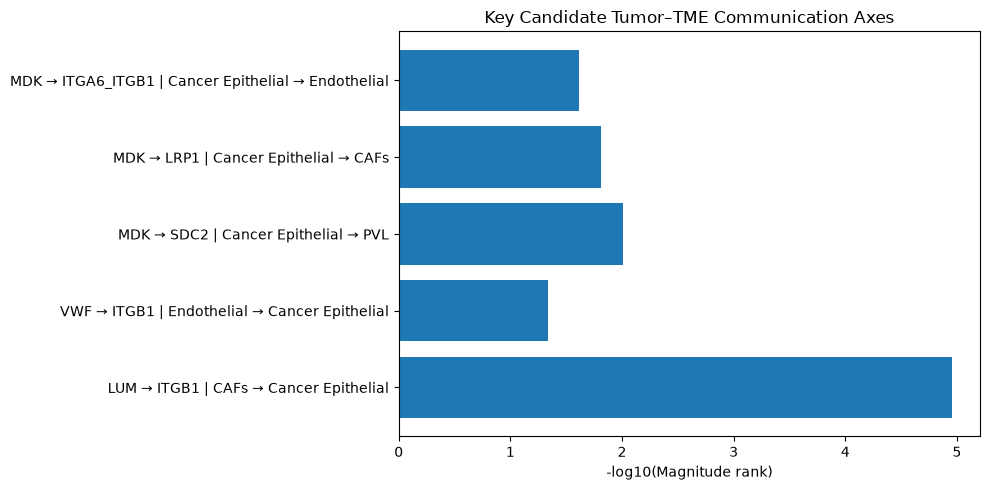

In [32]:
summary_df = pd.DataFrame({
    "axis": [
        "CAFs → Cancer Epithelial",
        "Endothelial → Cancer Epithelial",
        "Cancer Epithelial → PVL",
        "Cancer Epithelial → CAFs",
        "Cancer Epithelial → Endothelial"
    ],
    "interaction": [
        "LUM → ITGB1",
        "VWF → ITGB1",
        "MDK → SDC2",
        "MDK → LRP1",
        "MDK → ITGA6_ITGB1"
    ],
    "magnitude_rank": [
        0.000011,
        0.046364,
        0.009703,
        0.015474,
        0.024502
    ]
})

summary_df["score"] = -np.log10(summary_df["magnitude_rank"])

plt.figure(figsize=(10, 5))

plt.barh(
    summary_df["interaction"] + " | " + summary_df["axis"],
    summary_df["score"]
)

plt.xlabel("-log10(Magnitude rank)")
plt.title("Key Candidate Tumor–TME Communication Axes")

plt.tight_layout()

plt.savefig(
    figures_dir / "06_key_tumor_tme_communication_axes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
print("=== FINAL CELL–CELL COMMUNICATION QC ===")

print(f"Cells analysed: {adata_liana.n_obs}")
print(f"Genes analysed: {adata_liana.n_vars}")
print(f"Major cell populations: {adata_liana.obs['celltype_major'].nunique()}")

print(f"\nTotal LIANA interactions: {len(liana_res)}")
print(f"Tumor-centered interactions: {len(tumor_interactions)}")
print(f"Tumor–TME interactions excluding tumor self-signaling: {len(tumor_tme)}")
print(f"High-ranking exploratory tumor–TME interactions: {len(top_tumor_tme)}")

print("\nKey candidate communication axes:")

print("Stromal/endothelial → tumor:")
print("- CAFs: LUM → ITGB1")
print("- Endothelial: VWF → ITGB1")

print("\nTumor → stromal/endothelial:")
print("- Cancer Epithelial → PVL: MDK → SDC2")
print("- Cancer Epithelial → CAFs: MDK → LRP1")
print("- Cancer Epithelial → Endothelial: MDK → ITGA6_ITGB1")

print("\nInterpretation:")
print(
    "LIANA identified recurrent candidate tumor–TME communication patterns, "
    "including ITGB1-centered stromal/endothelial signaling toward cancer "
    "epithelial cells and MDK-centered signaling from cancer epithelial cells "
    "toward stromal compartments."
)

=== FINAL CELL–CELL COMMUNICATION QC ===
Cells analysed: 1525
Genes analysed: 13514
Major cell populations: 8

Total LIANA interactions: 1807
Tumor-centered interactions: 615
Tumor–TME interactions excluding tumor self-signaling: 553
High-ranking exploratory tumor–TME interactions: 9

Key candidate communication axes:
Stromal/endothelial → tumor:
- CAFs: LUM → ITGB1
- Endothelial: VWF → ITGB1

Tumor → stromal/endothelial:
- Cancer Epithelial → PVL: MDK → SDC2
- Cancer Epithelial → CAFs: MDK → LRP1
- Cancer Epithelial → Endothelial: MDK → ITGA6_ITGB1

Interpretation:
LIANA identified recurrent candidate tumor–TME communication patterns, including ITGB1-centered stromal/endothelial signaling toward cancer epithelial cells and MDK-centered signaling from cancer epithelial cells toward stromal compartments.


## Conclusion

Exploratory ligand–receptor analysis using LIANA identified recurrent candidate
communication signals between cancer epithelial cells and major tumor
microenvironment compartments.

Two prominent communication patterns emerged:

1. Stromal and endothelial ligands converging on ITGB1-containing receptors in
   cancer epithelial cells, including LUM–ITGB1 and VWF–ITGB1.

2. Tumor-derived MDK signaling toward multiple stromal compartments, including
   MDK–SDC2 in PVL cells, MDK–LRP1 in CAFs, and MDK–ITGA6_ITGB1 in endothelial
   cells.

Additional candidate tumor–immune interactions included CD59–CD2,
S100A8–CD68, S100A8–CD69, and COPA–CD74.

Because this analysis is based on ligand–receptor expression inference in a
single TNBC sample, these interactions should be interpreted as candidate
communication events rather than experimentally validated signaling activity.